In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
data = {
    'Temperatur': [10, 25, 15, 20, 18, 20, 22, 24],
    'Kecepatan_Angin': [0, 0, 5, 3, 7, 10, 5, 0],
    'Klasifikasi': ['Dingin', 'Panas', 'Dingin', 'Panas', 'Dingin', 'Dingin', 'Panas', 'Panas']
}

df = pd.DataFrame(data)
target_suhu = 16
target_angin = 3

print("DATA AWAL:")
print(df)
print("\n" + "="*60 + "\n")

DATA AWAL:
   Temperatur  Kecepatan_Angin Klasifikasi
0          10                0      Dingin
1          25                0       Panas
2          15                5      Dingin
3          20                3       Panas
4          18                7      Dingin
5          20               10      Dingin
6          22                5       Panas
7          24                0       Panas




In [ ]:
df['Selisih Suhu'] = (df['Temperatur'] - target_suhu) ** 2
df['Selisih Angin'] = (df['Kecepatan_Angin'] - target_angin) ** 2

df['Jarak'] = np.sqrt(df['Selisih Suhu'] + df['Selisih Angin'])

print("Tabel Perhitungan Lengkap:")
print(df[['Temperatur', 'Kecepatan_Angin', 'Klasifikasi', 'Selisih Suhu', 'Selisih Angin', 'Jarak']])


hasil_manual = df_sorted.head(5)['Klasifikasi'].mode()[0]
print(f"Cuaca diprediksi {hasil_manual}")
print("\n" + "="*60 + "\n")

Tabel Perhitungan Lengkap:
   Temperatur  Kecepatan_Angin Klasifikasi  Selisih Suhu  Selisih Angin  \
0          10                0      Dingin            36              9   
1          25                0       Panas            81              9   
2          15                5      Dingin             1              4   
3          20                3       Panas            16              0   
4          18                7      Dingin             4             16   
5          20               10      Dingin            16             49   
6          22                5       Panas            36              4   
7          24                0       Panas            64              9   

      Jarak  
0  6.708204  
1  9.486833  
2  2.236068  
3  4.000000  
4  4.472136  
5  8.062258  
6  6.324555  
7  8.544004  
Cuaca diprediksi Dingin




In [ ]:
X = df[['Temperatur', 'Kecepatan_Angin']]
y = df['Klasifikasi']

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, y)

data_testing = [[target_suhu, target_angin]]
hasil_prediksi = knn.predict(data_testing)

print(f"Data Testing: Suhu={target_suhu}, Angin={target_angin}")
print(f"-> Hasil Prediksi Library Python: {hasil_prediksi[0]}")
print("\n" + "="*60 + "\n")

Data Testing: Suhu=16, Angin=3
-> Hasil Prediksi Library Python: Dingin




/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


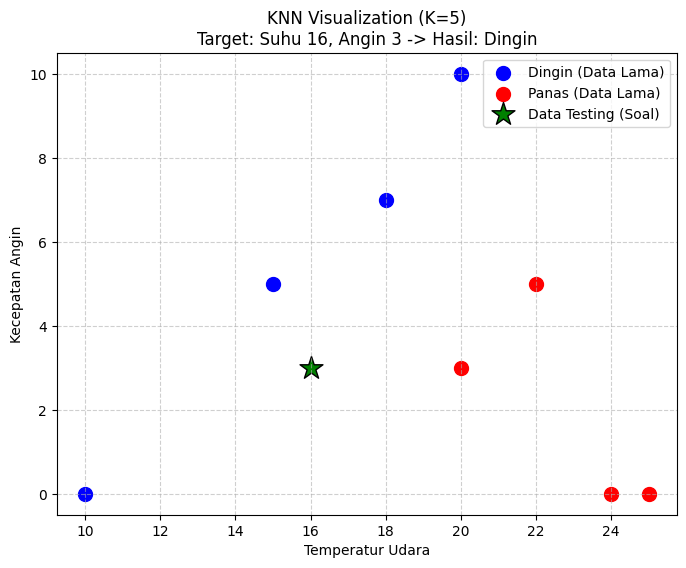

In [ ]:
dingin = df[df['Klasifikasi'] == 'Dingin']
panas = df[df['Klasifikasi'] == 'Panas']

plt.figure(figsize=(8, 6))


plt.scatter(dingin['Temperatur'], dingin['Kecepatan_Angin'], color='blue', label='Dingin (Data Lama)', s=100)
plt.scatter(panas['Temperatur'], panas['Kecepatan_Angin'], color='red', label='Panas (Data Lama)', s=100)


plt.scatter(target_suhu, target_angin, color='green', marker='*', s=300, label='Data Testing (Soal)', edgecolors='black')


plt.xlabel('Temperatur Udara')
plt.ylabel('Kecepatan Angin')
plt.title(f'KNN Visualization (K=5)\nTarget: Suhu {target_suhu}, Angin {target_angin} -> Hasil: {hasil_prediksi[0]}')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)


plt.show()